# RFM analysis and Pre-clustering process

This notebook contains the analysis of the final RFM table and the data transformation process necessary to achieve a successfull segmentation process in further steps. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "../data_raw/raw_rfm_metrics.csv"
df_rfm = pd.read_csv(path)

## RFM Table Validation

Before proceeding with transformation and clustering steps, it is essential to validate the structure and quality of the RFM dataset. This includes verifying data types, checking for missing or invalid values, and ensuring that the Recency, Frequency, and Monetary metrics have been correctly computed and are suitable for further analysis.

In [2]:
df_rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    5878 non-null   int64  
 1   Frequency  5878 non-null   int64  
 2   Monetary   5878 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 137.9 KB


In [3]:
df_rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,132.600034,2955.810211
std,209.338707,342.190038,14440.288735
min,1.000000,1.000000,2.950000
25%,26.000000,20.000000,342.280000
50%,96.000000,52.000000,867.740000
75%,380.000000,138.000000,2248.305000
max,739.000000,12435.000000,580987.040000


### Insights and conclusion

The RFM dataset contains 5,878 customers with no missing values across all three metrics, confirming data completeness. Additionally, all variables present valid ranges, with no negative values observed, which ensures consistency with the expected definitions of Recency, Frequency, and Monetary.

From a statistical perspective, the summary metrics reveal high variability across customers, particularly in Frequency and Monetary, as indicated by their large standard deviations relative to their means. The wide range between minimum and maximum values further confirms the presence of extreme values and a highly skewed distribution, which is consistent with previous EDA findings.

Overall, the dataset is structurally suitable for the transformation stage. However, the observed variability and skewness reinforce the need for applying distribution transformations and scaling before clustering.

## RFM Distribution Transformation

Based on the EDA findings from the Customer-Level Analysis, both Frequency and Monetary variables have extreme values and significant variability in customer behavior. This skewness can negatively impact clustering algorithms such as K-Means, as distance calculations may become disproportionately influenced by a small number of high-value observations.

To address this issue, a logarithmic transformation is applied to the Frequency and Monetary variables. This transformation reduces the effect of extreme values by compressing large magnitudes while preserving the relative differences between customers, resulting in a more balanced distribution for clustering purposes.

#### Data point distribution relative to Recency and Frequency before log transformation

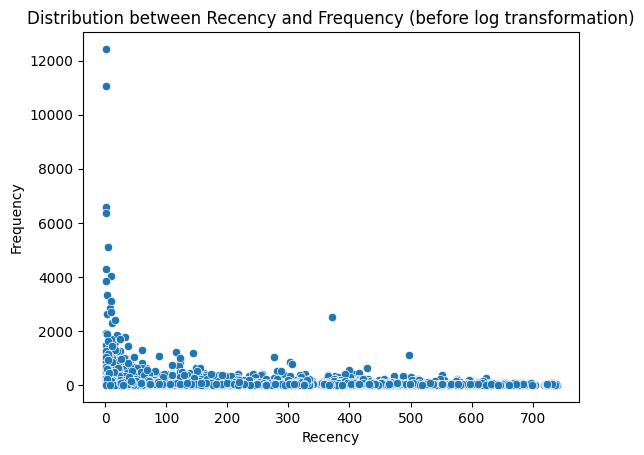

In [28]:
sns.scatterplot(data=df_rfm, x="Recency", y="Frequency") 
plt.title("Distribution between Recency and Frequency (before log transformation)") 
plt.show()

#### Data point distribution relative to Recency and Monetary value before log transformation

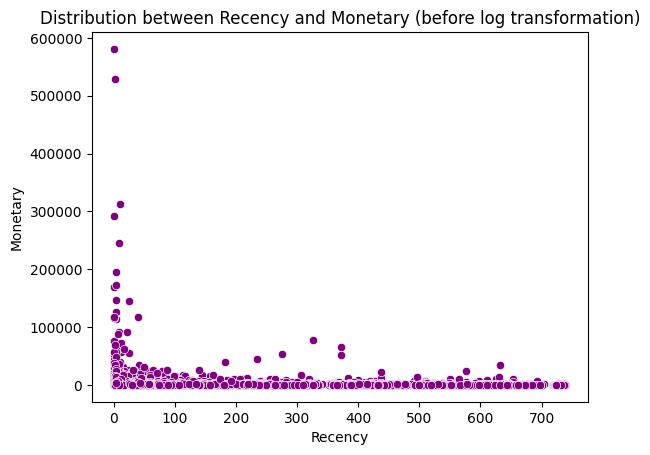

In [29]:
sns.scatterplot(data=df_rfm, x="Recency", y="Monetary", color="purple") 
plt.title("Distribution between Recency and Monetary (before log transformation)") 
plt.show()

### Logarithmic transformation process

In [30]:
df_rfm['Frequency_log'] = np.log1p(df_rfm['Frequency']) 
df_rfm['Monetary_log'] = np.log1p(df_rfm['Monetary'])

In [31]:
df_rfm.describe()

,Recency,Frequency,Monetary,Frequency_log,Monetary_log
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,201.331916,132.600034,2955.810211,3.978338,6.816977
std,209.338707,342.190038,14440.288735,1.359770,1.385482
min,1.000000,1.000000,2.950000,0.693147,1.373716
25%,26.000000,20.000000,342.280000,3.044522,5.838546
50%,96.000000,52.000000,867.740000,3.970292,6.767044
75%,380.000000,138.000000,2248.305000,4.934474,7.718377
max,739.000000,12435.000000,580987.040000,9.428351,13.272485


### Frequency and monetary distributions after log transformations

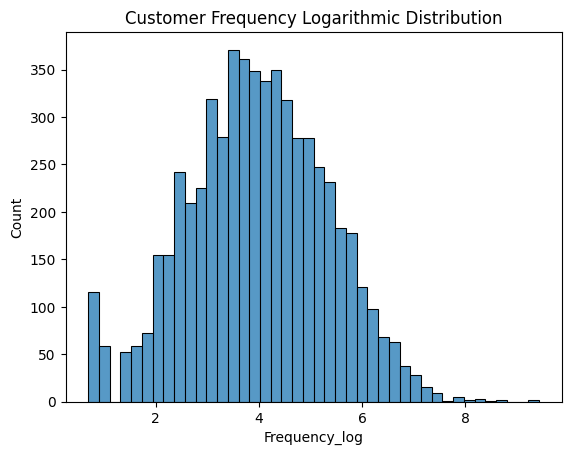

In [32]:
sns.histplot(x=df_rfm['Frequency_log']) 
plt.title("Customer Frequency Logarithmic Distribution") 
plt.show()

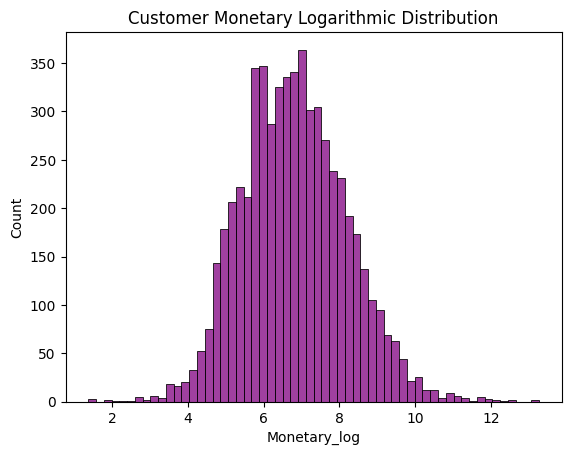

In [36]:
sns.histplot(x=df_rfm['Monetary_log'], color="purple") 
plt.title("Customer Monetary Logarithmic Distribution") 
plt.show()

#### Data point distribution relative to Recency and Frequency after log transformation

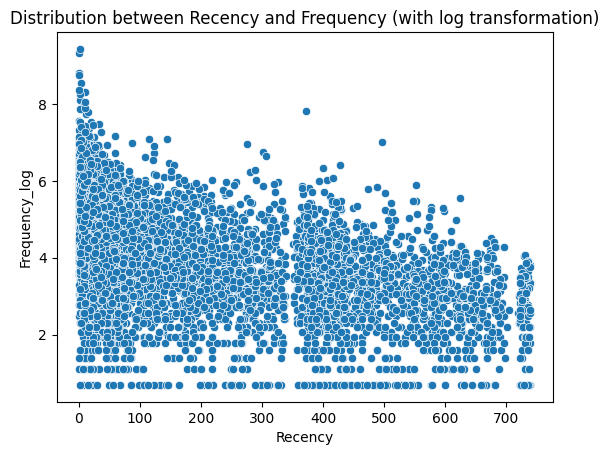

In [34]:
sns.scatterplot(data=df_rfm, x="Recency", y="Frequency_log") 
plt.title("Distribution between Recency and Frequency (with log transformation)") 
plt.show()

#### Data point distribution relative to Recency and Monetary value after log transformation

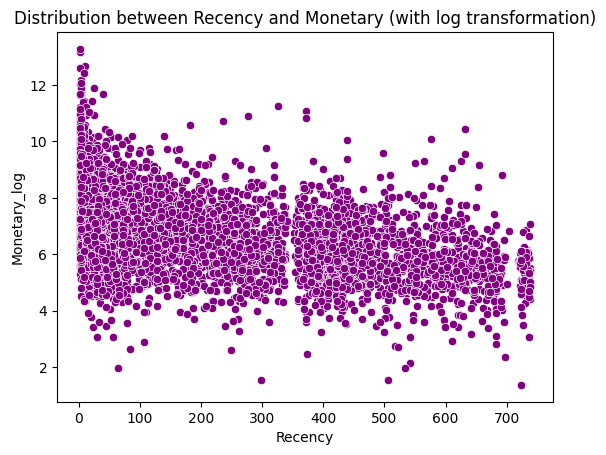

In [35]:
sns.scatterplot(data=df_rfm, x="Recency", y="Monetary_log", color="purple") 
plt.title("Distribution between Recency and Monetary (with log transformation)") 
plt.show()

### Insights and Results

The application of the logarithmic transformation significantly reduces the skewness observed in the original Frequency and Monetary distributions. As shown in the histograms, both variables become more evenly distributed and with extreme values compressed.

Additionally, the scatterplots illustrate a more compact and interpretable structure of the data, where the influece of extreme outliers is lower in the overall distribution.

It is important to note that the goal of the transformation is not to achieve a perfectly normal distribution, but rather to reduce the impact of extreme values and improve the effectiveness of distance-based algorithms such as K-Means.

Overall, this transformation step enhances the quality of the input data, enabling more meaningful and stable customer segmentation in the subsequent clustering phase.